In [226]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import os

In [227]:
df_41 = pd.read_csv("../ValgrindGraphics/OutFiles/massif_hs_ack_41.csv")
df_312 = pd.read_csv("../ValgrindGraphics/OutFiles/massif_hs_ack_312.csv")

dir = "graphics/Valgrind/"

In [228]:
LOGO_PATHS = {
    "C": "images/C_Logo.png",
    "Python": "images/Python_Logo.png",
    "JavaScript": "images/JavaScript_Logo.png",
    "Haskell": "images/Haskell_Logo.png"
}

In [229]:
def add_logo_to_plot(ax, language, x_pos=0.5, y_pos=0.5, zoom=0.08):
    target_height = 405
    
    img = Image.open(LOGO_PATHS[language]).convert("RGBA")
    ratio = target_height / img.height
    new_width = int(img.width * ratio)
    img = img.resize((new_width, target_height))

    imagebox = OffsetImage(img, zoom=zoom)
    ab = AnnotationBbox(
        imagebox,
        (x_pos, y_pos),
        xybox=(0, 0),
        frameon=False,
        xycoords='axes fraction',
        boxcoords="offset points",
        pad=0
    )

    ax.add_artist(ab)

In [230]:
def plot_massif_style(title, language, input_size, filename):

    if language == "C":
        df_41["mem_kib"] = df_41["mem_stacks_B"] / 1024
        df_312["mem_kib"] = df_312["mem_stacks_B"] / 1024
        mem = "mem_kib"
        mem_type = "KiB"

        df_41["time_i"] = df_41["time"] / 1e9
        time_41 = "time ($10^{10}$ instructions)"
        df_312["time_i"] = df_312["time"] / 1e9
        time_312 = "time (10⁹ instructions)"

        max_y = max(df_41["mem_kib"].max(), df_312["mem_kib"].max())
    elif language == "Python":
        df_41["mem_mb"] = df_41["mem_heap_B"] / 1e6
        df_312["mem_mb"] = df_312["mem_heap_B"] / 1e6
        mem = "mem_mb"
        mem_type = "MiB"

        df_41["time_i"] = df_41["time"] / 1e12
        time_41 = "time ($10^{12}$ instructions)"
        df_312["time_i"] = df_312["time"] / 1e11
        time_312 = "time ($10^{11}$ instructions)"

        max_y = max(df_41["mem_mb"].max(), df_312["mem_mb"].max())
    elif language == "JavaScript":
        df_41["mem_mb"] = (df_41["mem_heap_B"] + df_41["mem_stacks_B"] + df_41["mem_heap_extra_B"]) / 1e6
        df_312["mem_mb"] = (df_312["mem_heap_B"] + df_312["mem_stacks_B"] + df_312["mem_heap_extra_B"]) / 1e6
        mem = "mem_mb"
        mem_type = "MiB"

        df_41["time_i"] = df_41["time"] / 1e11
        time_41 = "time ($10^{11}$ instructions)"
        df_312["time_i"] = df_312["time"] / 1e10
        time_312 = "time ($10^{10}$ instructions)"

        max_y = max(df_41["mem_mb"].max(), df_312["mem_mb"].max())
    else:
        df_41["mem_mb"] = (df_41["mem_heap_B"] + df_41["mem_stacks_B"] + df_41["mem_heap_extra_B"]) / 1e6
        df_312["mem_mb"] = (df_312["mem_heap_B"] + df_312["mem_stacks_B"] + df_312["mem_heap_extra_B"]) / 1e6
        mem = "mem_mb"
        mem_type = "MiB"

        df_41["time_i"] = df_41["time"] / 1e11
        time_41 = "time ($10^{11}$ instructions)"
        df_312["time_i"] = df_312["time"] / 1e11
        time_312 = "time ($10^{11}$ instructions)" 

        max_y = max(df_41["mem_mb"].max(), df_312["mem_mb"].max())

    max_y *= 1.1
    
    if input_size == '312':
        df = df_312
        color = '#ff914d'
        time = time_312
    else: 
        df = df_41
        color = '#4c8dcf'
        time = time_41

    peak_idx = df[mem].idxmax()
    peak_x = df.loc[peak_idx, "time_i"]
    peak_y = df.loc[peak_idx, mem]

    plt.figure()

    plt.plot(df["time_i"], df[mem], color=color)
    plt.fill_between(df["time_i"], df[mem], color=color, alpha=0.25)

    plt.scatter(peak_x, peak_y, color = color)
    plt.text(peak_x, peak_y, f"{peak_y:.4f} {mem_type}")

    plt.xlabel(time)
    plt.ylabel(f"memory heap consumption {mem_type}")
    plt.title(title)

    plt.ylim(0, max_y)

    plt.margins(x=0)
    plt.xlim(0, df["time_i"].max())

    ax = plt.gca()
    add_logo_to_plot(ax, language, x_pos= -0.10, y_pos= -0.10, zoom=0.05)

    plt.subplots_adjust(bottom=0.2)
    plt.savefig(f"{dir}{filename}.png", dpi=300, bbox_inches="tight")

    plt.show()

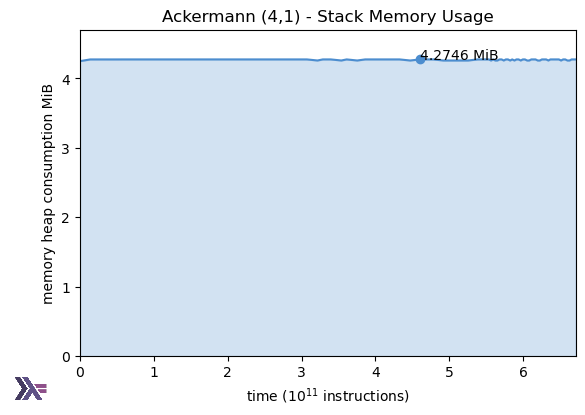

In [231]:
plot_massif_style("Ackermann (4,1) - Stack Memory Usage", "Haskell", "41", "valgrind_hs_4_1")

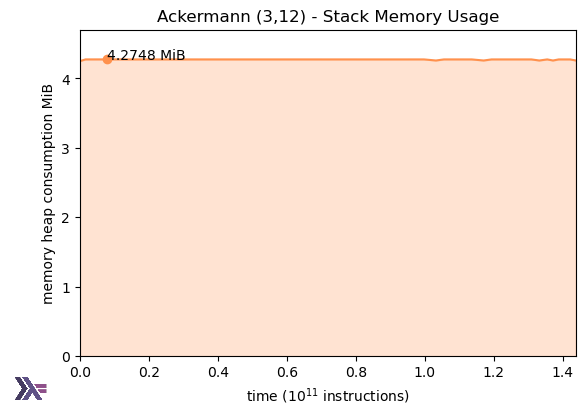

In [232]:
plot_massif_style("Ackermann (3,12) - Stack Memory Usage", "Haskell", "312", "valgrind_hs_3_12")

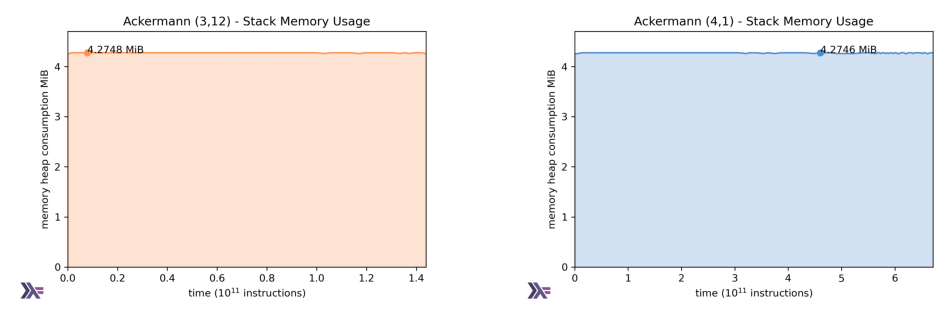

In [233]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

img1 = mpimg.imread(dir + "valgrind_hs_3_12.png")
img2 = mpimg.imread(dir + "valgrind_hs_4_1.png")

ax[0].imshow(img1)
ax[0].axis("off")
# ax[0].set_title("Powercap")


ax[1].imshow(img2)
ax[1].axis("off")
# ax[1].set_title("No Powercap")

plt.savefig(f"{dir}memory_consumption_hs.png", dpi=300, bbox_inches="tight")

plt.show()